In [1]:
import math
import time
from pathlib import Path

import numpy as np
from statsmodels.stats.multitest import multipletests
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
## PATH ##

outdir = "/mnt/sdb/scz_meta_analysis_processed/mash_results/power_simulation_45condition/"
CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

In [3]:
# Simulation Imports ##

results = pd.read_csv(Path(outdir) / "mash_power_simulation_45condition_results.csv")

summary_results = pd.read_csv(Path(outdir) / "mash_power_simulation_45condition_summary.csv")

In [4]:
## Read in DEG Lists at CellType Level ##

# by manuscript #
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_3q29 = dge_purcell

In [5]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [6]:
## Calculate FDR at CellType Level ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

# Merge Significance Def #

dge_3q29['significant_fdr'] = (dge_3q29['adj.P.Val'] < 0.05)
dge_15q13['significant_fdr'] = (dge_15q13['adj.P.Val'] < 0.05)

dge_3q29['estimate'] = dge_3q29['logFC'] 
dge_15q13['estimate'] = dge_15q13['logFC']

In [7]:
# Celltype #

all_celltypes = pd.concat([dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                                dge_nrxn1.assign(group='NRXN1del'), 
                                dge_22q11.assign(group='22q11.2del'),
                                dge_3q29.assign(group='3q29.del'),
                                dge_15q13.assign(group='15q13del')], axis=0)

significant_celltypes = all_celltypes[all_celltypes['significant_fdr']]

In [8]:
# Mash Analysis #

dfn_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Dorsal_Forebrain_Neuron_FOXG1+EMX1+NEUROG1+_all.csv')
rg_vim_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+VIM+FABP7+_all.csv')
rg_pax_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+PAX6+FABP7+_all.csv')
mc_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mesenchymal-like_cells_VIM+VCAN+SPARC+_all.csv')
gaba_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_GABAergic_GAD1+GAD2+CALB2+_all.csv')
prg_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Proliferative_Radial_Glia_SOX2+HES6+TOP2A+_all.csv')
ipc_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_IPC_EOMES+NEUROG2+PAX6+_all.csv')
mn_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mixed_Neurons_FGF12+GRIN2B+CAMK2B+_all.csv')
astro_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Astrocyte_GFAP+AQP4+HOPX+_all.csv')

combined = pd.DataFrame({
    "gene": dfn_composite["gene"],
    "score_dfn": dfn_composite["score"],
    "score_rg_vim": rg_vim_composite["score"],
    "score_rg_pax": rg_pax_composite["score"],
    "score_mc": mc_composite["score"],
    "score_gaba": gaba_composite["score"],
    "score_prg": prg_composite["score"],
    "score_ipc": ipc_composite["score"],
    "score_mn": mn_composite["score"],
    "score_astro": astro_composite["score"],
})

combined = combined.set_index("gene")

combined.rename({'score_dfn':'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
                 'score_rg_vim':'Radial Glia SOX2+VIM+FABP7+',
                 'score_rg_pax':'Radial Glia SOX2+PAX6+FABP7+',
                 'score_mc':'Mesenchymal-like cells VIM+VCAN+SPARC+',
                 'score_gaba':'GABAergic GAD1+GAD2+CALB2+',
                 'score_prg':'Proliferative Radial Glia SOX2+HES6+TOP2A+',
                 'score_ipc':'IPC EOMES+NEUROG2+PAX6+',
                 'score_mn':'Mixed Neurons FGF12+GRIN2B+CAMK2B+',
                 'score_astro':'Astrocyte GFAP+AQP4+HOPX+'}, axis=1, inplace=True)

In [9]:
celltypes = ["Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+","Radial Glia SOX2+VIM+FABP7+",
             "Radial Glia SOX2+PAX6+FABP7+", "Proliferative Radial Glia SOX2+HES6+TOP2A+",
            "Mixed Neurons FGF12+GRIN2B+CAMK2B+", "Hindbrain Neurons NR2F2+PBX3+LHX1+"]

In [10]:
celltype_colors = {
    "Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+": "#ff7f0e",
    "Radial Glia SOX2+VIM+FABP7+": "#98df8a",
    "Radial Glia SOX2+PAX6+FABP7+": "#ffbb78",
    "Proliferative Radial Glia SOX2+HES6+TOP2A+": "#aec7e8",
    "Mixed Neurons FGF12+GRIN2B+CAMK2B+": "#e377c2",
    "Hindbrain Neurons NR2F2+PBX3+LHX1+": "#d62728",
    "Mesenchymal-like cells VIM+VCAN+SPARC+": "#8c564b",
    "Astrocyte GFAP+AQP4+HOPX+": "#1f77b4",
    "IPC EOMES+NEUROG2+PAX6+": "#aa40fc",
    "GABAergic GAD1+GAD2+CALB2+": "#279e68",
    "OPC OLIG1+OLIG2+PDGFRA+": "#b5bd61",
    "Oligodendrocyte OLIG1+OLIG2+MBP+": "#17becf",
}

In [11]:
((0.5 < np.abs(significant_celltypes['estimate'])) & (np.abs(significant_celltypes['estimate']) < 4)).sum() / significant_celltypes.shape[0]

0.910119356512714

In [12]:
(0.5 < np.abs(significant_celltypes['estimate'])).sum() / significant_celltypes.shape[0]

0.9128178515827712

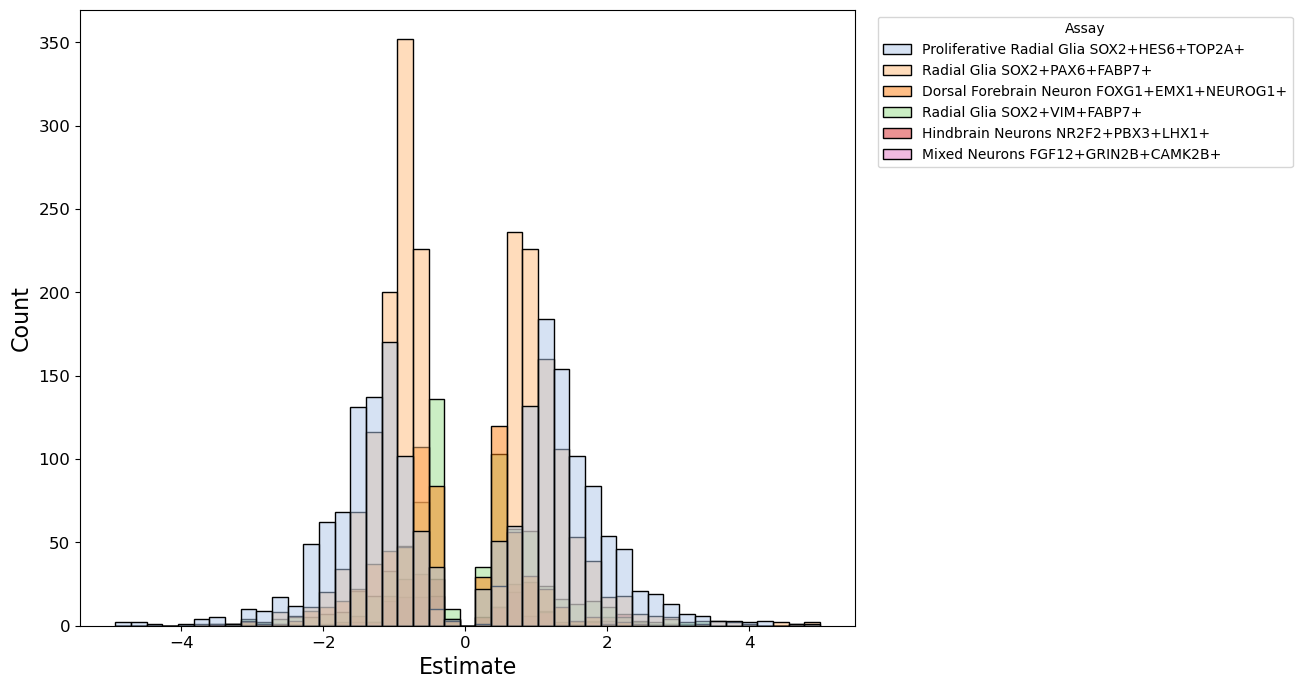

In [13]:
## Remove Untested Celltypes ##

fig, ax = plt.subplots(figsize=(10, 8))

tested_sig_celltypes = significant_celltypes[significant_celltypes['assay'].isin(['Proliferative Radial Glia SOX2+HES6+TOP2A+',
                                     'Radial Glia SOX2+PAX6+FABP7+',
                                     'Radial Glia SOX2+VIM+FABP7+',
                                     'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
                                     'Hindbrain Neurons NR2F2+PBX3+LHX1+',
                                     'Mixed Neurons FGF12+GRIN2B+CAMK2B+'])]

sns.histplot(data=tested_sig_celltypes, palette=celltype_colors, x='estimate', hue='assay', ax=ax)

ax.set_xlabel('Estimate', fontsize=16)
ax.set_ylabel('Count', fontsize=16)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

sns.move_legend(ax, 'upper left', bbox_to_anchor=(1.02, 1), title='Assay')

# plt.tight_layout()
plt.savefig('/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Figure_Mash_Power_significant_celltypes_tested_histplot.svg', 
            dpi=300, bbox_inches='tight')
plt.show()

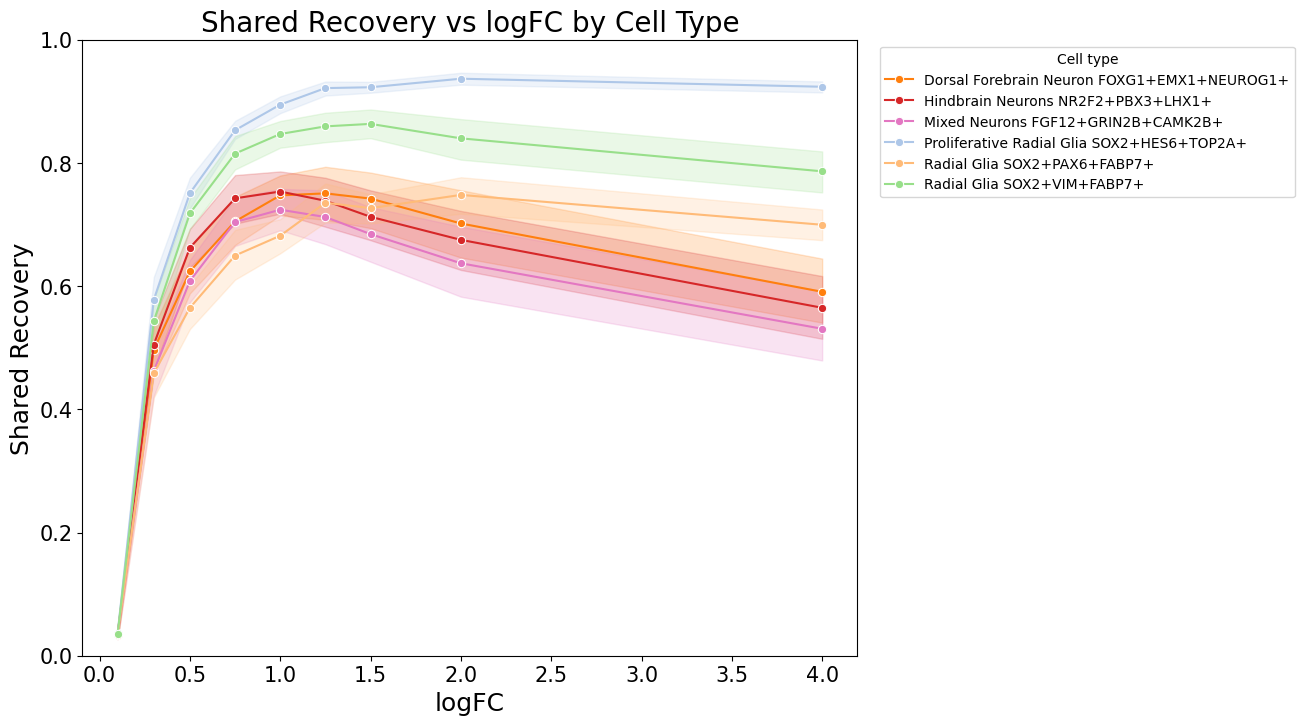

In [14]:
cols = ['shared_recovery_Dorsal_Forebrain_Neuron_FOXG1_EMX1_NEUROG1_',
        'shared_recovery_Hindbrain_Neurons_NR2F2_PBX3_LHX1_',
        'shared_recovery_Mixed_Neurons_FGF12_GRIN2B_CAMK2B_',
        'shared_recovery_Proliferative_Radial_Glia_SOX2_HES6_TOP2A_',
        'shared_recovery_Radial_Glia_SOX2_PAX6_FABP7_',
        'shared_recovery_Radial_Glia_SOX2_VIM_FABP7_']


plot_data = results.melt(id_vars='logFC', value_vars=cols, var_name='celltype', value_name='shared_recovery_perc')
plot_data['celltype'] = plot_data['celltype'].str.replace('shared_recovery_', '', regex=False).str.rstrip('_')

plot_data['celltype'] = plot_data['celltype'].replace({
    'Dorsal_Forebrain_Neuron_FOXG1_EMX1_NEUROG1': 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
    'Hindbrain_Neurons_NR2F2_PBX3_LHX1': 'Hindbrain Neurons NR2F2+PBX3+LHX1+',
    'Mixed_Neurons_FGF12_GRIN2B_CAMK2B': 'Mixed Neurons FGF12+GRIN2B+CAMK2B+',
    'Proliferative_Radial_Glia_SOX2_HES6_TOP2A': 'Proliferative Radial Glia SOX2+HES6+TOP2A+',
    'Radial_Glia_SOX2_PAX6_FABP7': 'Radial Glia SOX2+PAX6+FABP7+',
    'Radial_Glia_SOX2_VIM_FABP7': 'Radial Glia SOX2+VIM+FABP7+'
})

fig, ax = plt.subplots(figsize=(10, 8))

sns.lineplot(data=plot_data, x='logFC', y='shared_recovery_perc', hue='celltype', marker='o', palette=celltype_colors, ax=ax)

ax.set_xlabel('logFC', fontsize=18)
ax.set_ylabel('Shared Recovery', fontsize=18)
ax.set_ylim(0, 1)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_title('Shared Recovery vs logFC by Cell Type', fontsize=20)
ax.legend(title='Cell type', bbox_to_anchor=(1.02, 1), loc='upper left')

# plt.tight_layout()
plt.savefig('/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Figure_Mash_Power_Shared_Recovery_by_logFC.svg', 
            dpi=300, bbox_inches='tight')
plt.show()

In [15]:
mean_at_03 = plot_data[plot_data['logFC'] == 0.3].groupby('celltype')['shared_recovery_perc'].mean().sort_values(ascending=False)

print(mean_at_03)

celltype
Proliferative Radial Glia SOX2+HES6+TOP2A+     0.577733
Radial Glia SOX2+VIM+FABP7+                    0.543022
Hindbrain Neurons NR2F2+PBX3+LHX1+             0.505067
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    0.496489
Mixed Neurons FGF12+GRIN2B+CAMK2B+             0.462000
Radial Glia SOX2+PAX6+FABP7+                   0.458622
Name: shared_recovery_perc, dtype: float64


In [16]:
mean_at_05 = plot_data[plot_data['logFC'] == 0.5].groupby('celltype')['shared_recovery_perc'].mean().sort_values(ascending=False)

print(mean_at_05)

celltype
Proliferative Radial Glia SOX2+HES6+TOP2A+     0.750933
Radial Glia SOX2+VIM+FABP7+                    0.718133
Hindbrain Neurons NR2F2+PBX3+LHX1+             0.662444
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    0.623822
Mixed Neurons FGF12+GRIN2B+CAMK2B+             0.608444
Radial Glia SOX2+PAX6+FABP7+                   0.564800
Name: shared_recovery_perc, dtype: float64


In [17]:
## Generate CellType Average Recovery by logFC ##

recovery_cols = [c for c in results.columns if c.startswith("shared_recovery_")]

celltype_mean_by_logFC = results.groupby(["logFC"])[recovery_cols].mean().reset_index()

celltype_mean_by_logFC.columns = [i.strip('shared_recovery_') for i in celltype_mean_by_logFC.columns]

celltype_mapping = {"Dorsal_Forebrain_Neuron_FOXG1_EMX1_NEUROG1": "Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+",
                    "Radial_Glia_SOX2_VIM_FABP7": "Radial Glia SOX2+VIM+FABP7+",
                    "Radial_Glia_SOX2_PAX6_FABP7": "Radial Glia SOX2+PAX6+FABP7+",
                    "Proliferative_Radial_Glia_SOX2_HES6_TOP2A": "Proliferative Radial Glia SOX2+HES6+TOP2A+",
                    "Mixed_Neurons_FGF12_GRIN2B_CAMK2B": "Mixed Neurons FGF12+GRIN2B+CAMK2B+",
                    "Hindbrain_Neurons_NR2F2_PBX3_LHX1": "Hindbrain Neurons NR2F2+PBX3+LHX1+"}

celltype_mean_by_logFC.rename(celltype_mapping, axis=1, inplace=True)

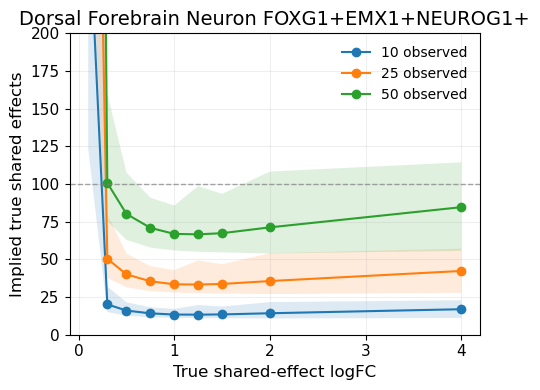

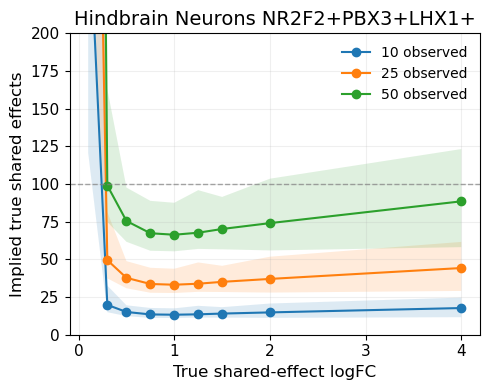

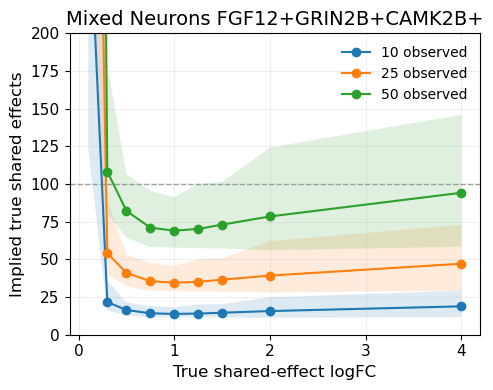

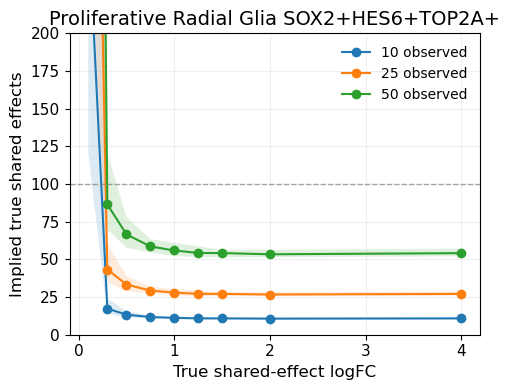

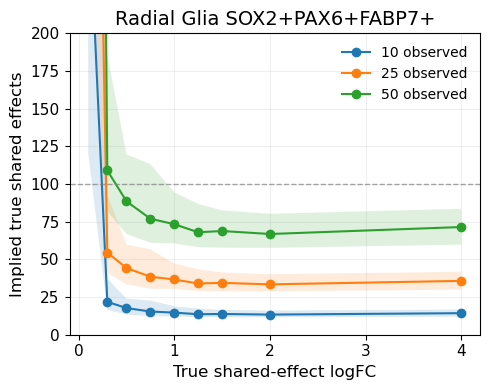

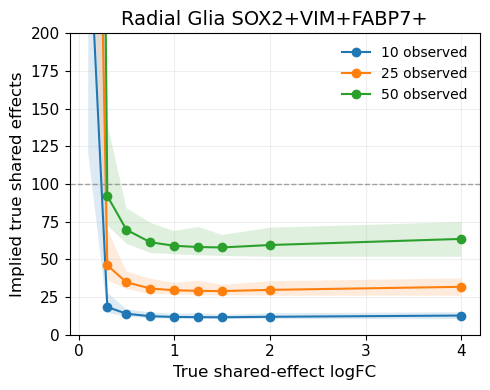

In [18]:
recovery_cols = [c for c in results.columns if c.startswith("shared_recovery_")]

recovery_long = results.melt(id_vars=["logFC"], value_vars=recovery_cols, var_name="celltype", value_name="recovery")

recovery_summary = recovery_long.groupby(["celltype", "logFC"])["recovery"].agg(mean="mean", lower=lambda x: x.quantile(0.025), upper=lambda x: x.quantile(0.975)).reset_index()

celltype_mapping = {"shared_recovery_Dorsal_Forebrain_Neuron_FOXG1_EMX1_NEUROG1_": "Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+", "shared_recovery_Radial_Glia_SOX2_VIM_FABP7_": "Radial Glia SOX2+VIM+FABP7+", "shared_recovery_Radial_Glia_SOX2_PAX6_FABP7_": "Radial Glia SOX2+PAX6+FABP7+", "shared_recovery_Proliferative_Radial_Glia_SOX2_HES6_TOP2A_": "Proliferative Radial Glia SOX2+HES6+TOP2A+", "shared_recovery_Mixed_Neurons_FGF12_GRIN2B_CAMK2B_": "Mixed Neurons FGF12+GRIN2B+CAMK2B+", "shared_recovery_Hindbrain_Neurons_NR2F2_PBX3_LHX1_": "Hindbrain Neurons NR2F2+PBX3+LHX1+"}

recovery_summary["celltype"] = recovery_summary["celltype"].map(celltype_mapping)

observed_levels = [10, 25, 50]

for celltype in recovery_summary["celltype"].unique():
    
    fig, ax = plt.subplots(figsize=(5, 4))

    tmp = recovery_summary[recovery_summary["celltype"] == celltype].sort_values("logFC")

    for n in observed_levels:
        ax.plot(tmp["logFC"], n / tmp["mean"], marker="o", label=f"{n} observed")
        ax.fill_between(tmp["logFC"], n / tmp["upper"], n / tmp["lower"], alpha=0.15)

    ax.set_title(celltype, fontsize=14)
    ax.set_xlabel("True shared-effect logFC", fontsize=12)
    ax.set_ylabel("Implied true shared effects", fontsize=12)
    ax.tick_params(axis="both", labelsize=11)
    ax.set_ylim(0, 200)
    ax.axhline(100, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.grid(alpha=0.2)

    ax.legend(frameon=False, fontsize=10)

    plt.tight_layout()
    plt.savefig(f'/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Figure_Mash_Power_Implied_True_vs_True_Shared_LogFC_{celltype}.svg', bbox_inches='tight')
    plt.show()
    plt.close()
